In [130]:
import sys
import os
import numpy as np 

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor

In [131]:
processor = LogProcessor('../../logs/nothingbot@16_03_2025_1321.log')
processor.read_log()

In [132]:
df = processor.activites_log
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,RAINFOREST_RESIN,10002,1,9996.0,2.0,9995.0,29.0,10004,2,10005.0,29.0,NaN,NaN,10003.0,0.0
1,-1,0,KELP,2028,1,2026.0,2.0,2025.0,29.0,2029,31,NaN,NaN,NaN,NaN,2028.5,0.0
2,-1,100,KELP,2025,24,NaN,NaN,NaN,NaN,2028,2,2029.0,22.0,NaN,NaN,2026.5,0.0
3,-1,100,RAINFOREST_RESIN,9996,2,9995.0,22.0,NaN,NaN,10004,2,10005.0,22.0,NaN,NaN,10000.0,0.0
4,-1,200,RAINFOREST_RESIN,9995,20,NaN,NaN,NaN,NaN,10005,20,NaN,NaN,NaN,NaN,10000.0,0.0


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
kelp_data = df[df['product']=="KELP"]
resin_data = df[df['product']=="RAINFOREST_RESIN"]

# Note: All data used in this study was taken from the nothing bot, so this is data of the market if only the bots trade against each other.

# Study 1.1: Checking micro-price midprice dependence for rainforest_resin.

C:\Users\Conrad\AppData\Local\Temp\ipykernel_3780\939686697.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resin_data['micro_price'] = microprice


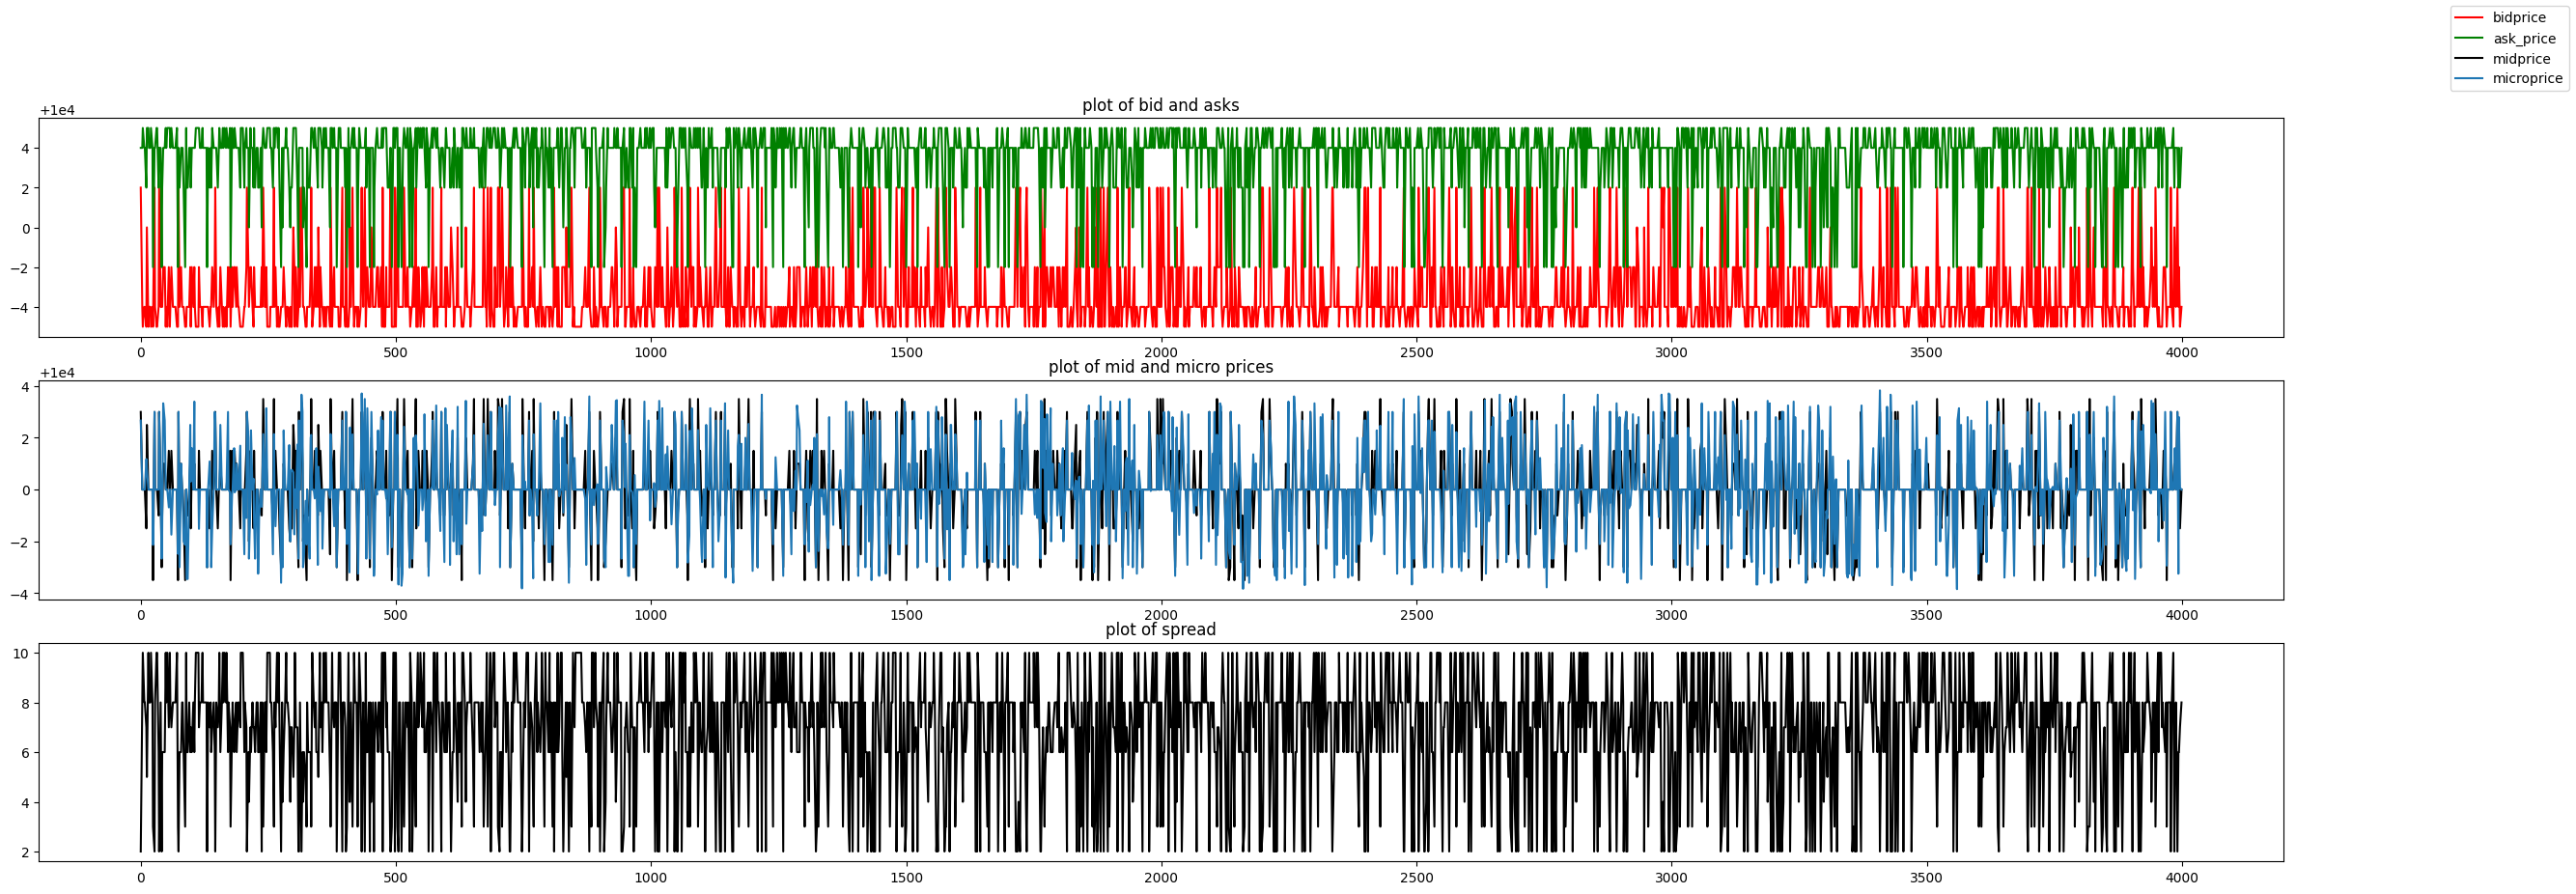

In [135]:
fig,ax = plt.subplots(nrows=3,figsize=(30,10))
ax[0].plot(resin_data.bid_price_1, color='red',label='bidprice')
ax[0].plot(resin_data.ask_price_1, color='green',label='ask_price')
ax[0].set_title('plot of bid and asks')
ax[1].plot(resin_data.mid_price,label='midprice',color='black')
microprice = resin_data.bid_price_1*resin_data.ask_volume_1+resin_data.ask_price_1*resin_data.bid_volume_1
microprice /= resin_data.ask_volume_1 + resin_data.bid_volume_1
resin_data['micro_price'] = microprice
ax[1].plot(resin_data.micro_price, label="microprice")
ax[1].set_title('plot of mid and micro prices')
spread = resin_data.ask_price_1-resin_data.bid_price_1
ax[2].plot(spread,color='black')
ax[2].set_title('plot of spread')
fig.legend()

The visual above has the x-axis as 10000 +- the integers on the x axis. We can see that it fluctuates a small amount around this range.

Text(0.5, 1.0, 'micro price relative to spread')

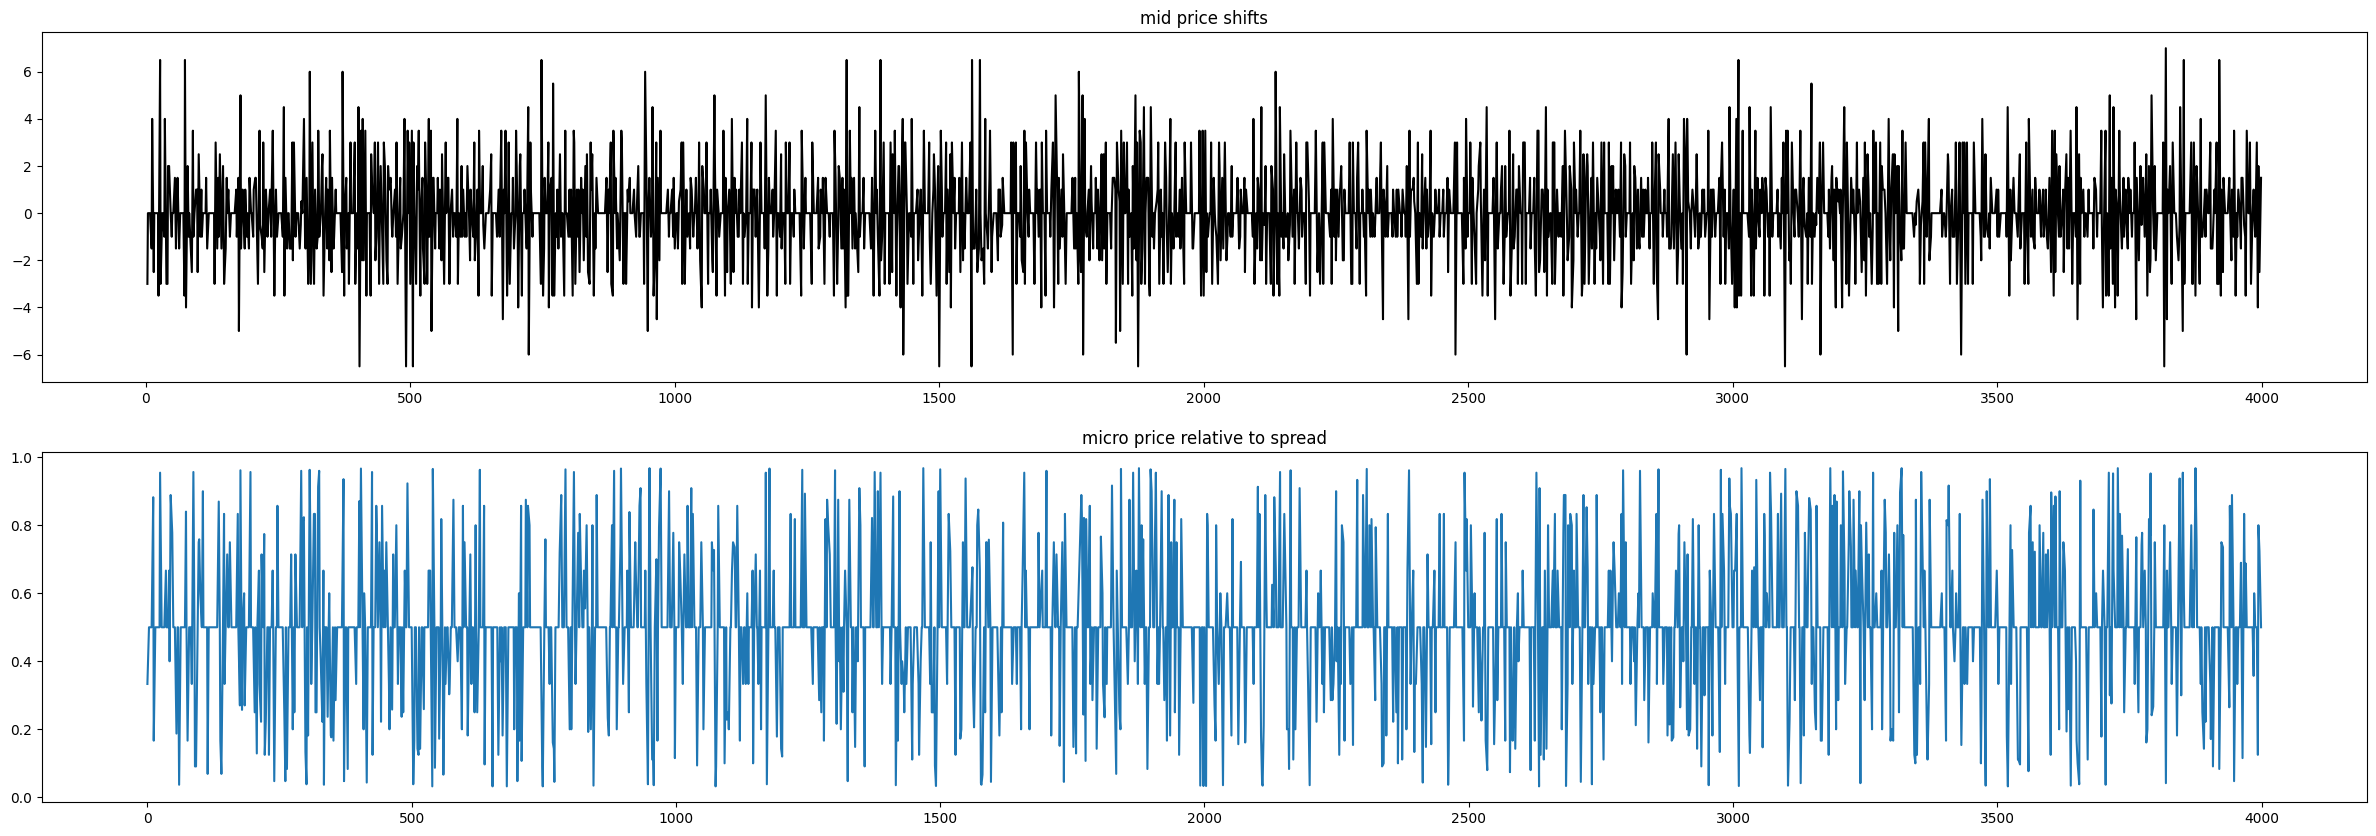

In [136]:
mid_price_shifts = resin_data.mid_price.diff()
micro_price_relative_to_spread = (resin_data.micro_price-resin_data.bid_price_1)/spread
fig,ax = plt.subplots(nrows=2,figsize=(30,10))
ax[0].plot(mid_price_shifts,color='black')
ax[0].set_title('mid price shifts')
ax[1].plot(micro_price_relative_to_spread)
ax[1].set_title('micro price relative to spread')

The above visual shows the microprice - the integer part of the microprice.

Hypothesis: The midprice shifts when the microprice gets close to one end.
</br>
Thus if we plot a chart of microprice shifts against midprice shifts, we should see no shift or small shifts for the relative microprice values close to 0.5 and then larger shifts for relative microprice values close to 1 and 0, with a positive shift if close to 1 and negative if close to 0.

Text(0, 0.5, 'mid price shifts')

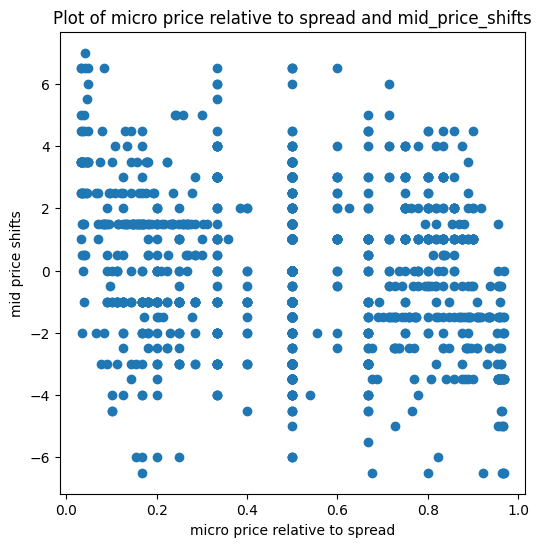

In [137]:
fig,ax = plt.subplots(figsize=(6,6))
ax.scatter(micro_price_relative_to_spread,mid_price_shifts)
ax.set_title('Plot of micro price relative to spread and mid_price_shifts')
ax.set_xlabel('micro price relative to spread')
ax.set_ylabel('mid price shifts')

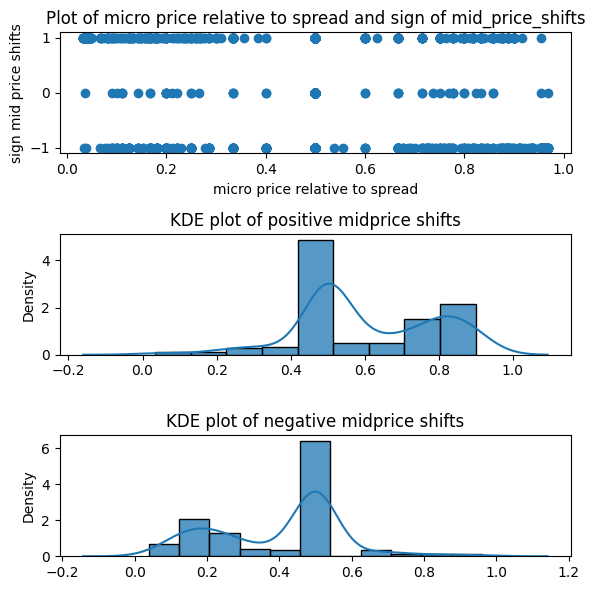

In [138]:
fig,ax = plt.subplots(nrows=3,figsize=(6,6))
ax[0].scatter(micro_price_relative_to_spread,np.sign(mid_price_shifts))
ax[0].set_title('Plot of micro price relative to spread and sign of mid_price_shifts')
ax[0].set_xlabel('micro price relative to spread')
ax[0].set_ylabel('sign mid price shifts')

sns.kdeplot(micro_price_relative_to_spread[mid_price_shifts == 1],ax=ax[1])
sns.histplot(micro_price_relative_to_spread[mid_price_shifts == 1],ax=ax[1],stat='density')
ax[1].set_title('KDE plot of positive midprice shifts')

sns.kdeplot(micro_price_relative_to_spread[mid_price_shifts == -1],ax=ax[2])
sns.histplot(micro_price_relative_to_spread[mid_price_shifts == -1],ax=ax[2],stat='density')
ax[2].set_title('KDE plot of negative midprice shifts')

fig.tight_layout()

Scatter plot does not reveal much, but KDE plot shows a clear correlation between the sign of the midprice shifts to the microprice relative to the spread.

# Study 1.2: Checking micro-price midprice dependence for Kelp.

C:\Users\Conrad\AppData\Local\Temp\ipykernel_3780\1141358716.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kelp_data['micro_price'] = microprice


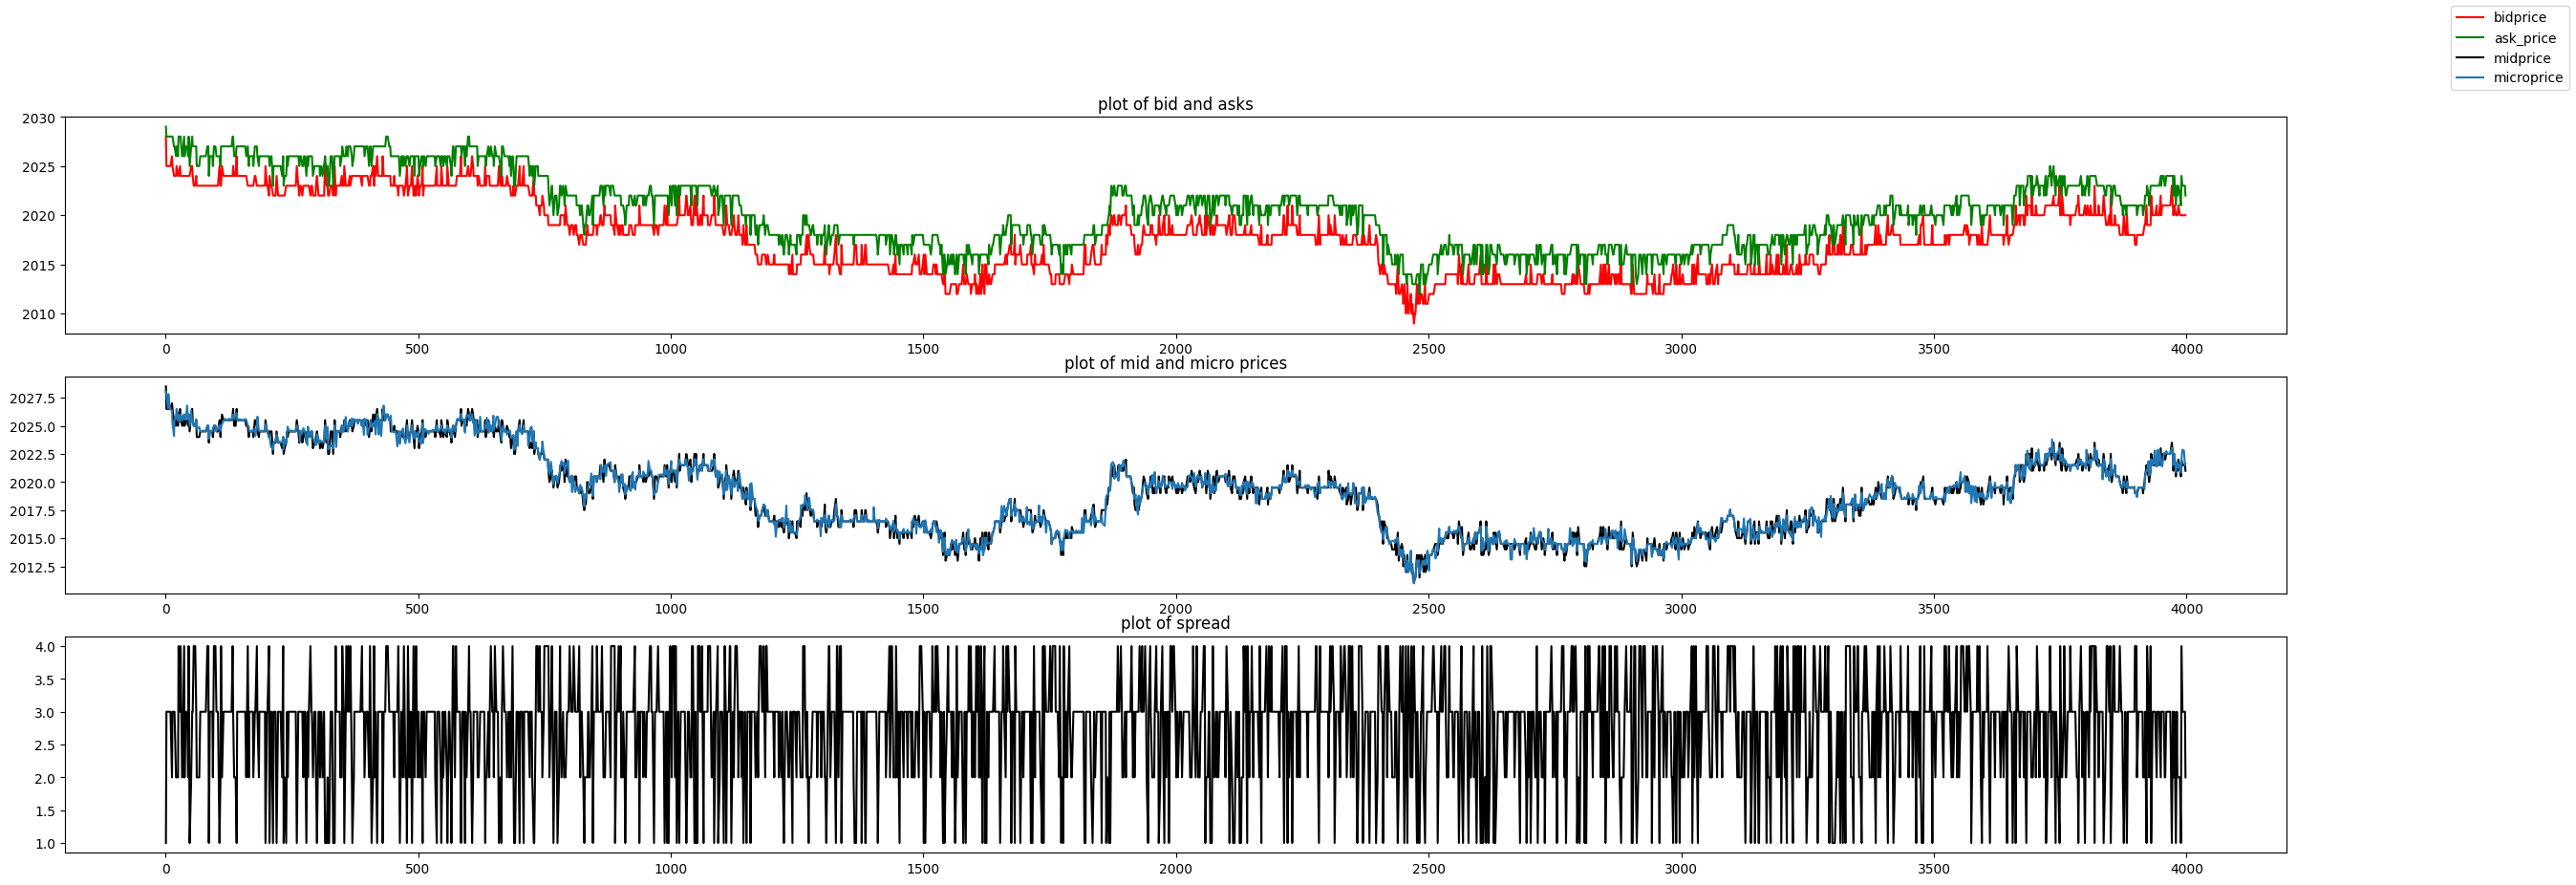

In [139]:
fig,ax = plt.subplots(nrows=3,figsize=(30,10))
ax[0].plot(kelp_data.bid_price_1, color='red',label='bidprice')
ax[0].plot(kelp_data.ask_price_1, color='green',label='ask_price')
ax[0].set_title('plot of bid and asks')
ax[1].plot(kelp_data.mid_price,label='midprice',color='black')
microprice = kelp_data.bid_price_1*kelp_data.ask_volume_1+kelp_data.ask_price_1*kelp_data.bid_volume_1
microprice /= kelp_data.ask_volume_1 + kelp_data.bid_volume_1
kelp_data['micro_price'] = microprice
ax[1].plot(kelp_data.micro_price, label="microprice")
ax[1].set_title('plot of mid and micro prices')
spread = kelp_data.ask_price_1-kelp_data.bid_price_1
ax[2].plot(spread,color='black')
ax[2].set_title('plot of spread')
fig.legend()

Text(0.5, 1.0, 'micro price relative to spread')

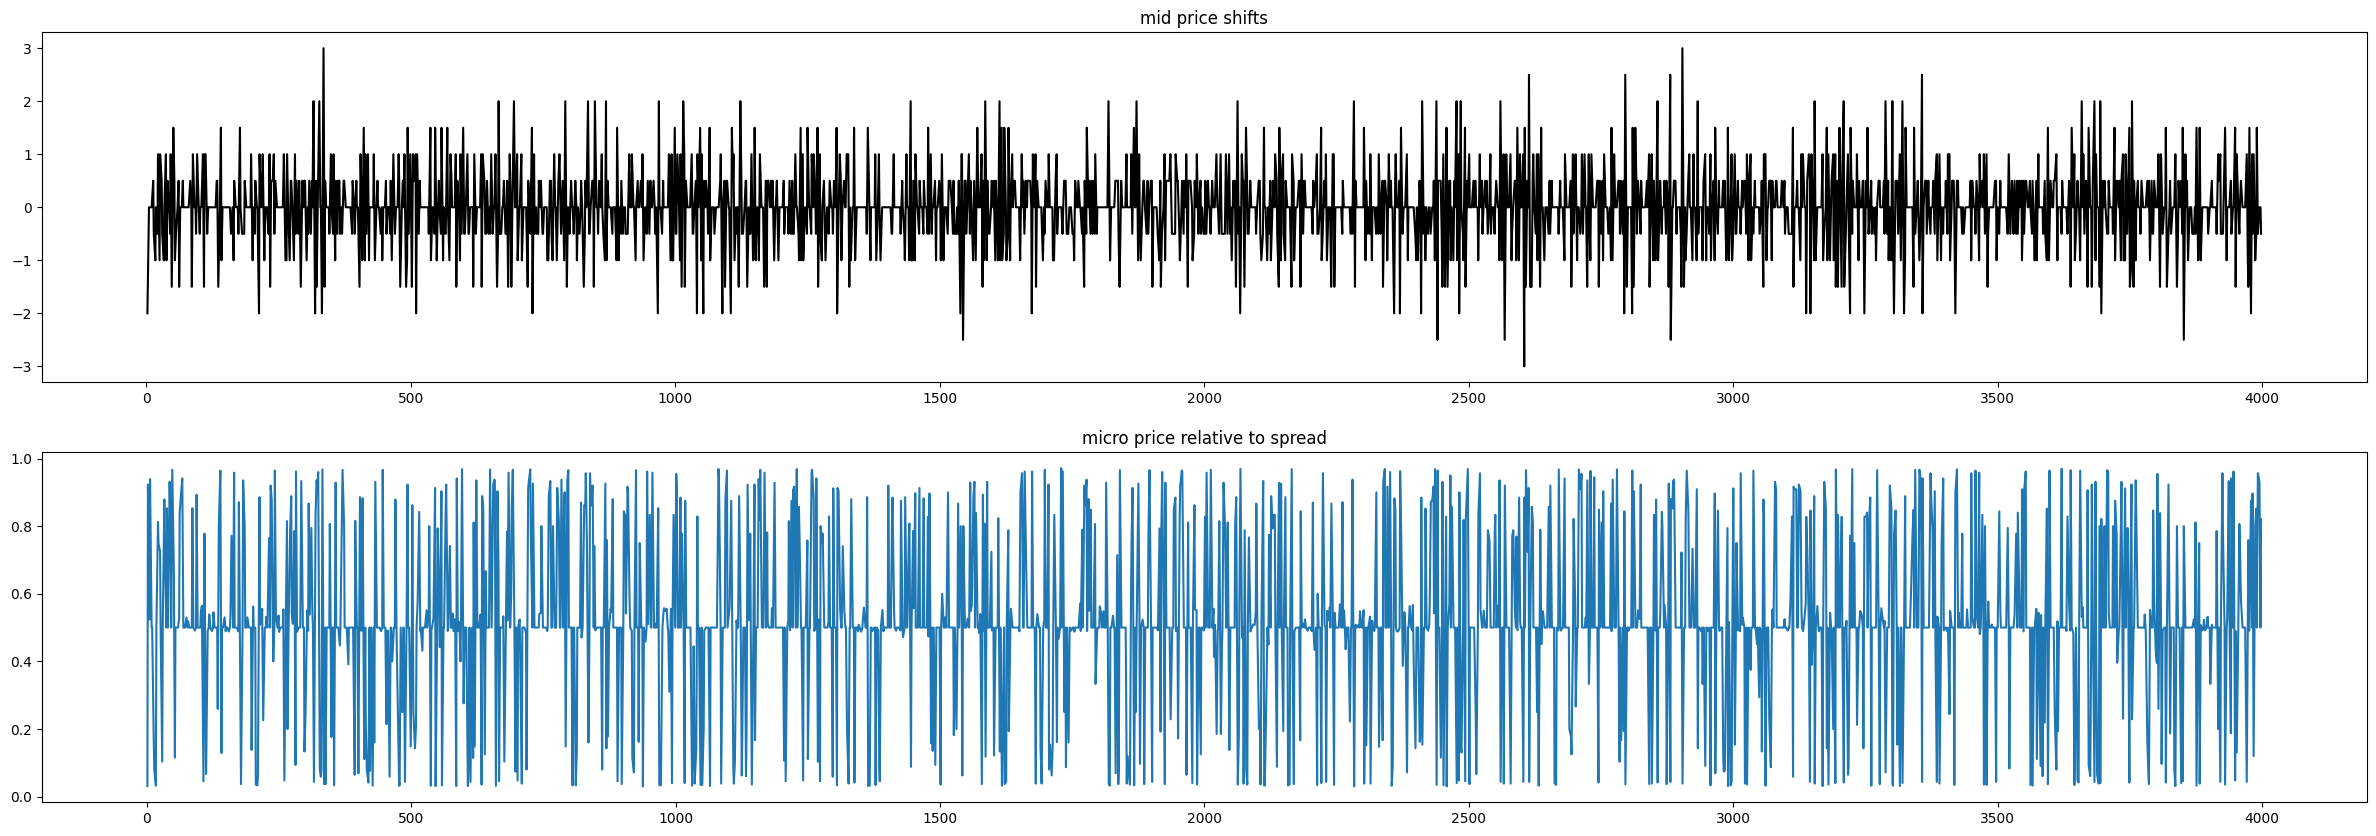

In [140]:
mid_price_shifts = kelp_data.mid_price.diff()
micro_price_relative_to_spread = (kelp_data.micro_price-kelp_data.bid_price_1)/spread
fig,ax = plt.subplots(nrows=2,figsize=(30,10))
ax[0].plot(mid_price_shifts,color='black')
ax[0].set_title('mid price shifts')
ax[1].plot(micro_price_relative_to_spread)
ax[1].set_title('micro price relative to spread')

Text(0, 0.5, 'mid price shifts')

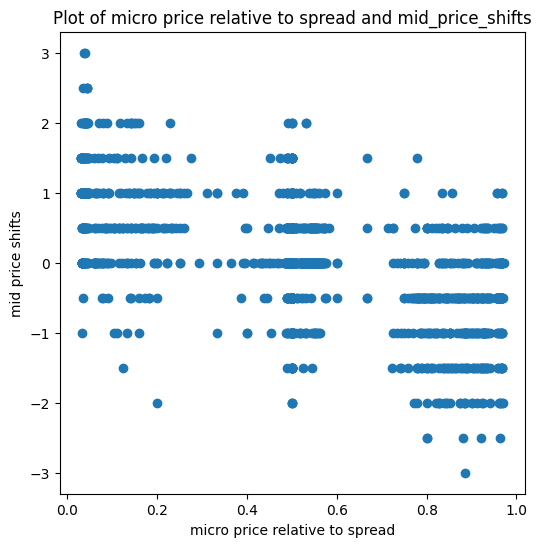

In [141]:
fig,ax = plt.subplots(figsize=(6,6))
ax.scatter(micro_price_relative_to_spread,mid_price_shifts)
ax.set_title('Plot of micro price relative to spread and mid_price_shifts')
ax.set_xlabel('micro price relative to spread')
ax.set_ylabel('mid price shifts')

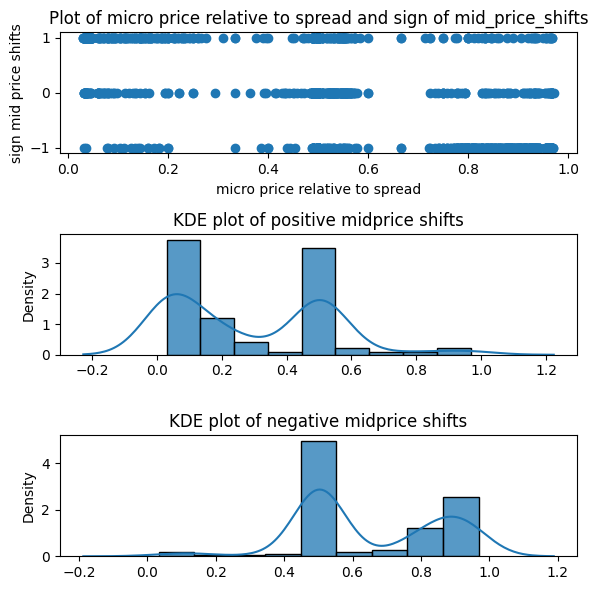

In [142]:
fig,ax = plt.subplots(nrows=3,figsize=(6,6))
ax[0].scatter(micro_price_relative_to_spread,np.sign(mid_price_shifts))
ax[0].set_title('Plot of micro price relative to spread and sign of mid_price_shifts')
ax[0].set_xlabel('micro price relative to spread')
ax[0].set_ylabel('sign mid price shifts')

sns.kdeplot(micro_price_relative_to_spread[mid_price_shifts == 1],ax=ax[1])
sns.histplot(micro_price_relative_to_spread[mid_price_shifts == 1],ax=ax[1],stat='density')
ax[1].set_title('KDE plot of positive midprice shifts')

sns.kdeplot(micro_price_relative_to_spread[mid_price_shifts == -1],ax=ax[2])
sns.histplot(micro_price_relative_to_spread[mid_price_shifts == -1],ax=ax[2],stat='density')
ax[2].set_title('KDE plot of negative midprice shifts')

fig.tight_layout()

Interestingly, the KDE plots show the opposite trend to that found in the rainforest resin one.

# Study 1.3: Looking into where the highest volume is on the order book at every time step (KELP)
Explanation: In last year's IMC competition, the 2nd place team looked at effective bids and asks by considering that sometimes the 2nd level of the bid/ask had the most volume rather than the top level. This study will look into if this trend is still the same for rainforest resin and kelp.

In [143]:
volumetric_data = kelp_data[['timestamp','bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3',]]
volumetric_data = volumetric_data.set_index('timestamp')
volumetric_data.head()

,bid_volume_1,bid_volume_2,bid_volume_3,ask_volume_1,ask_volume_2,ask_volume_3
timestamp,,,,,,
0,1,2.0,29.0,31,NaN,NaN
100,24,NaN,NaN,2,22.0,NaN
200,22,NaN,NaN,20,NaN,NaN
300,31,NaN,NaN,2,29.0,NaN
400,27,NaN,NaN,27,NaN,NaN


In [144]:
mapping_dict = {'bid_volume_1':1,'bid_volume_2':2,'bid_volume_3':3}
volumetric_data['highest_bid_vol_level'] = volumetric_data[['bid_volume_1','bid_volume_2','bid_volume_3']].idxmax(axis=1).map(mapping_dict)
mapping_dict = {'ask_volume_1':1,'ask_volume_2':2,'ask_volume_3':3}
volumetric_data['highest_ask_vol_level'] = volumetric_data[['ask_volume_1','ask_volume_2','ask_volume_3']].idxmax(axis=1).map(mapping_dict)

In [145]:
volumetric_data['highest_bid_vol_level'].value_counts()

highest_bid_vol_level
1    1618
2     349
3      33
Name: count, dtype: int64

In [146]:
volumetric_data['highest_ask_vol_level'].value_counts()

highest_ask_vol_level
1    1519
2     438
3      43
Name: count, dtype: int64

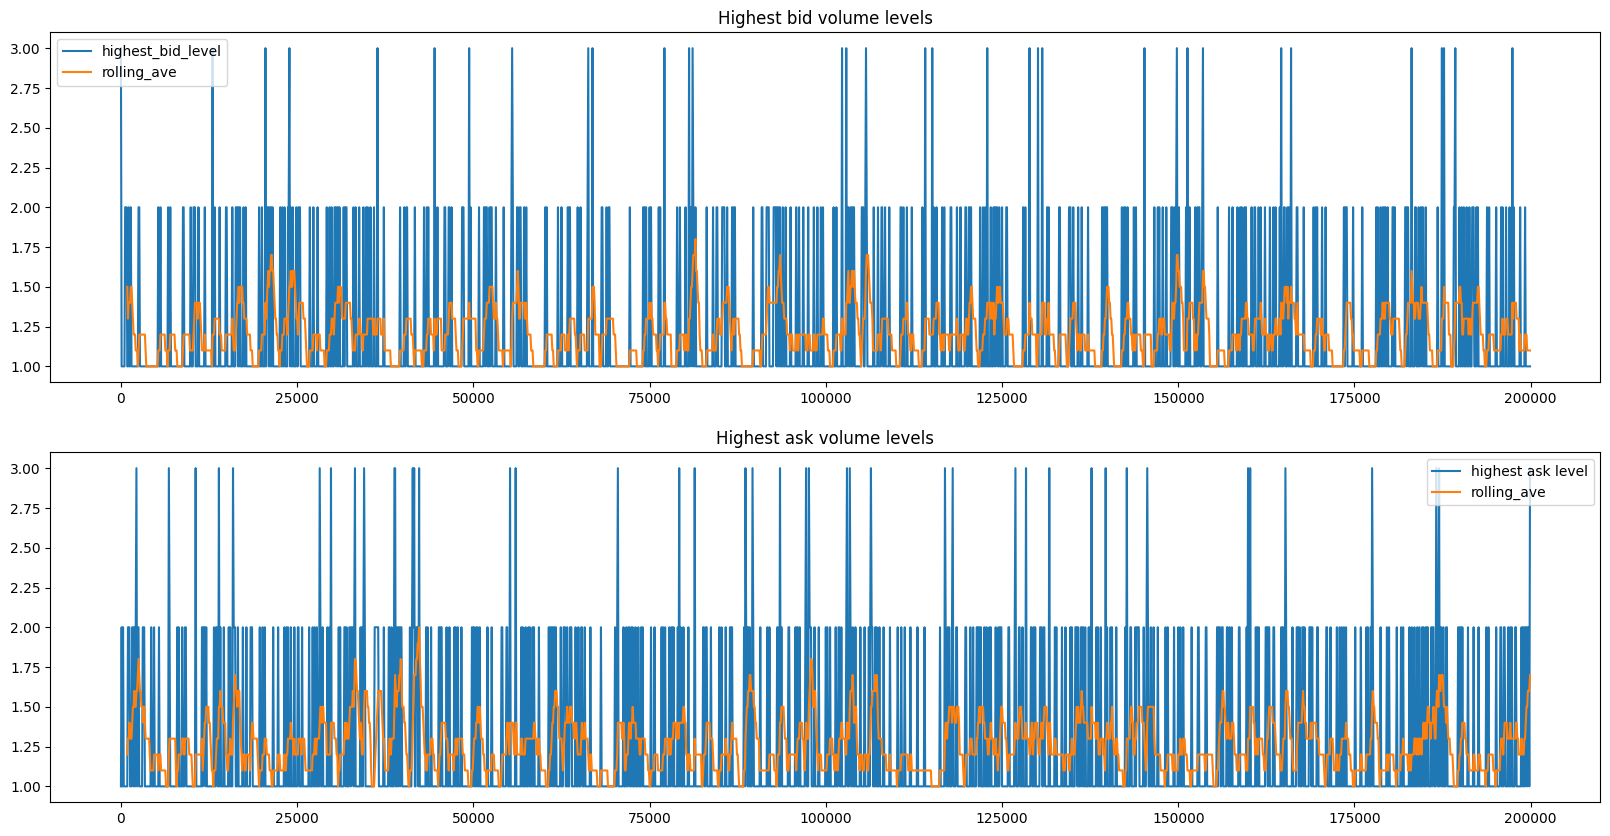

In [147]:
fig,ax = plt.subplots(nrows=2,figsize=(20,10))
ax[0].plot(volumetric_data['highest_bid_vol_level'], label='highest_bid_level')
ax[0].plot(volumetric_data['highest_bid_vol_level'].rolling(10).mean(),label='rolling_ave')
ax[0].set_title('Highest bid volume levels')
ax[0].legend()
ax[1].plot(volumetric_data['highest_ask_vol_level'],label='highest ask level')
ax[1].plot(volumetric_data['highest_ask_vol_level'].rolling(10).mean(),label='rolling_ave')
ax[1].set_title('Highest ask volume levels')
ax[1].legend()

Of note, we see that a non-trivial portion of timestamps have the highest volume at the second level rather than the first. Would have to look into how this correlates with the microprice relative to spread to see if this is already accounted for if we say use a strategy involving microprice.

# Study 1.4: Looking into where the highest volume is on the order book at every time step (RAINFOREST RESIN)

In [148]:
volumetric_data = resin_data[['timestamp','bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3',]]
volumetric_data = volumetric_data.set_index('timestamp')
volumetric_data.head()

,bid_volume_1,bid_volume_2,bid_volume_3,ask_volume_1,ask_volume_2,ask_volume_3
timestamp,,,,,,
0,1,2.0,29.0,2,29.0,NaN
100,2,22.0,NaN,2,22.0,NaN
200,20,NaN,NaN,20,NaN,NaN
300,2,29.0,NaN,2,29.0,NaN
400,2,25.0,NaN,2,25.0,NaN


In [149]:
mapping_dict = {'bid_volume_1':1,'bid_volume_2':2,'bid_volume_3':3}
volumetric_data['highest_bid_vol_level'] = volumetric_data[['bid_volume_1','bid_volume_2','bid_volume_3']].idxmax(axis=1).map(mapping_dict)
mapping_dict = {'ask_volume_1':1,'ask_volume_2':2,'ask_volume_3':3}
volumetric_data['highest_ask_vol_level'] = volumetric_data[['ask_volume_1','ask_volume_2','ask_volume_3']].idxmax(axis=1).map(mapping_dict)

In [150]:
volumetric_data['highest_bid_vol_level'].value_counts()

highest_bid_vol_level
2    1134
1     544
3     322
Name: count, dtype: int64

In [151]:
volumetric_data['highest_ask_vol_level'].value_counts()

highest_ask_vol_level
2    1165
1     548
3     287
Name: count, dtype: int64

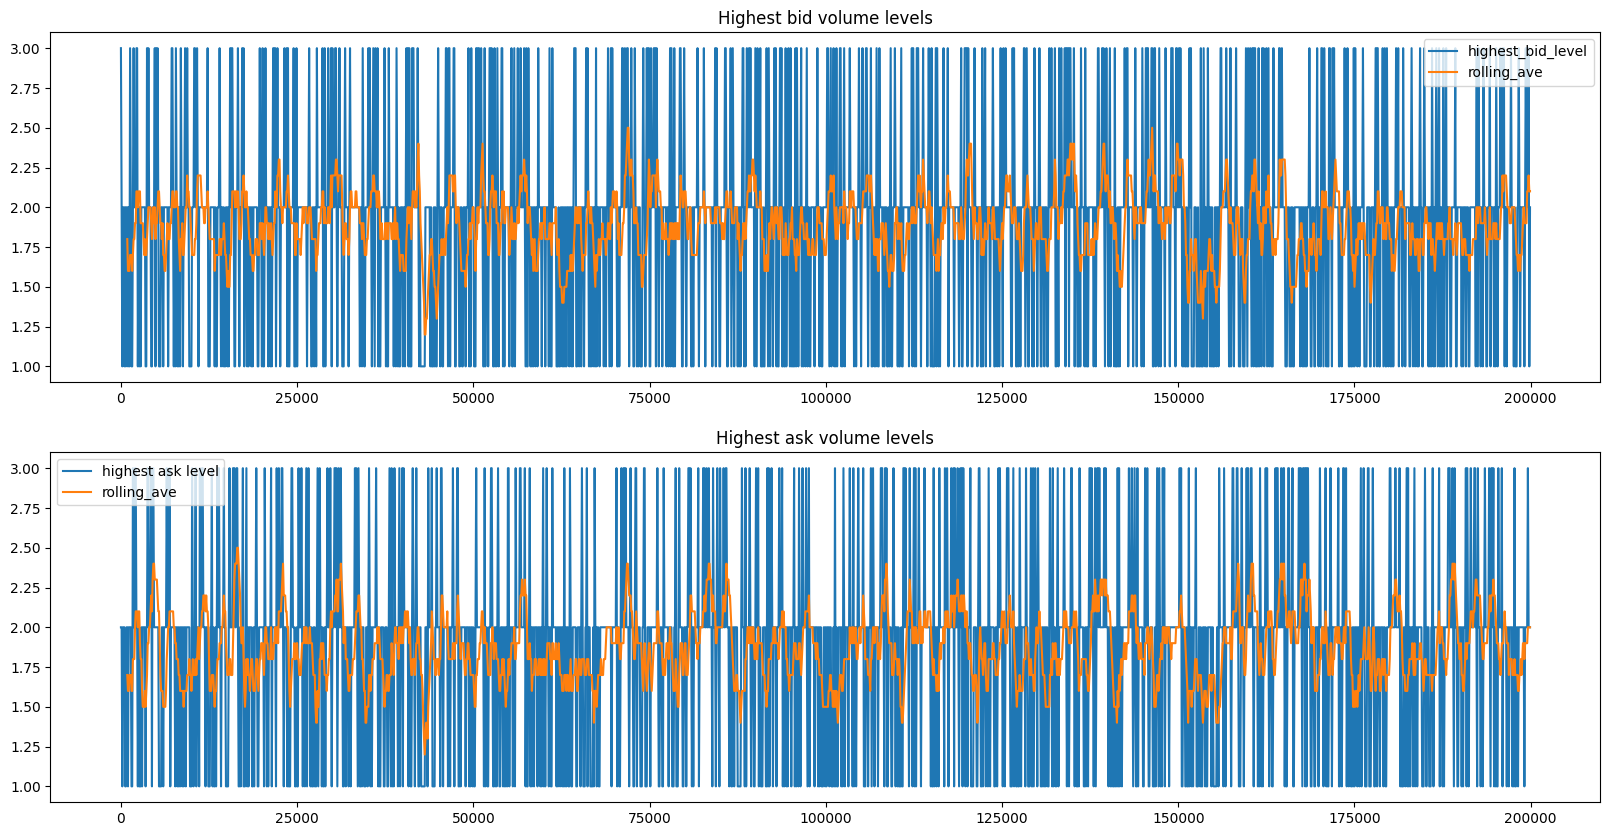

In [152]:
fig,ax = plt.subplots(nrows=2,figsize=(20,10))
ax[0].plot(volumetric_data['highest_bid_vol_level'], label='highest_bid_level')
ax[0].plot(volumetric_data['highest_bid_vol_level'].rolling(10).mean(),label='rolling_ave')
ax[0].set_title('Highest bid volume levels')
ax[0].legend()
ax[1].plot(volumetric_data['highest_ask_vol_level'],label='highest ask level')
ax[1].plot(volumetric_data['highest_ask_vol_level'].rolling(10).mean(),label='rolling_ave')
ax[1].set_title('Highest ask volume levels')
ax[1].legend()

Similar comment to the first. In fact a significant amount of volume is in the 3rd level for a lot of timestamps.

# Study 1.5: Looking into the correlation between the microprice relative to spread and the bid-ask levels (just to see if this is accounted for if we use just microprice). (KELP)

In [166]:
micro_price = kelp_data['micro_price']
micro_price_rel_spread = (micro_price-kelp_data['bid_price_1'])/(kelp_data['ask_price_1']-kelp_data['bid_price_1'])
volumetric_data = kelp_data[['timestamp','bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3',]]
mapping_dict = {'bid_volume_1':1,'bid_volume_2':2,'bid_volume_3':3}
volumetric_data['highest_bid_vol_level'] = volumetric_data[['bid_volume_1','bid_volume_2','bid_volume_3']].idxmax(axis=1).map(mapping_dict)
mapping_dict = {'ask_volume_1':1,'ask_volume_2':2,'ask_volume_3':3}
volumetric_data['highest_ask_vol_level'] = volumetric_data[['ask_volume_1','ask_volume_2','ask_volume_3']].idxmax(axis=1).map(mapping_dict)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_3780\3842217056.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumetric_data['highest_bid_vol_level'] = volumetric_data[['bid_volume_1','bid_volume_2','bid_volume_3']].idxmax(axis=1).map(mapping_dict)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_3780\3842217056.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumetric_data['highest_ask_vol_level'] = volumetric_data[['ask_volume_1','ask_volume_2','ask_volume_3']].idxmax(axis=1).map(mapping_dict)


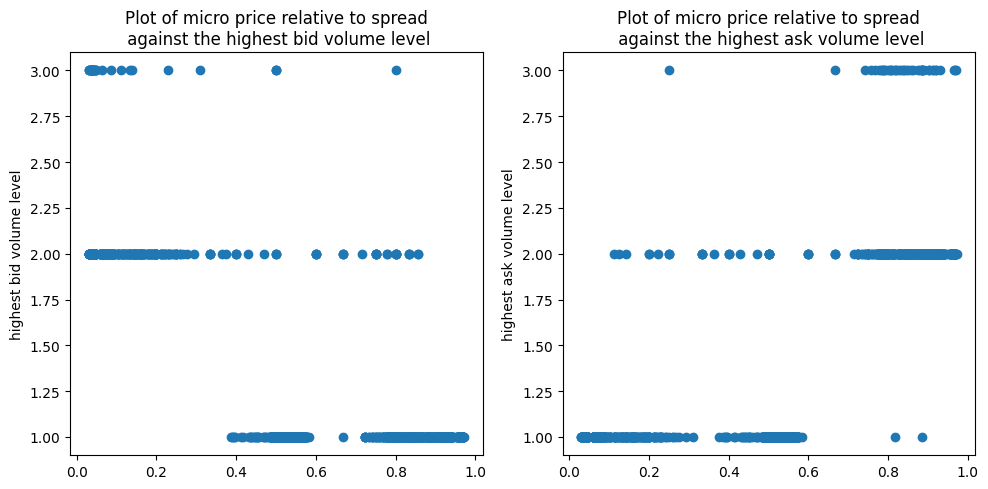

In [167]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,5))
ax[0].scatter(micro_price_rel_spread,volumetric_data['highest_bid_vol_level'])
ax[0].set_title('Plot of micro price relative to spread\n against the highest bid volume level')
ax[0].set_ylabel('highest bid volume level')
ax[1].scatter(micro_price_rel_spread,volumetric_data['highest_ask_vol_level'])
ax[1].set_title('Plot of micro price relative to spread\n against the highest ask volume level')
ax[1].set_ylabel('highest ask volume level')
fig.tight_layout()

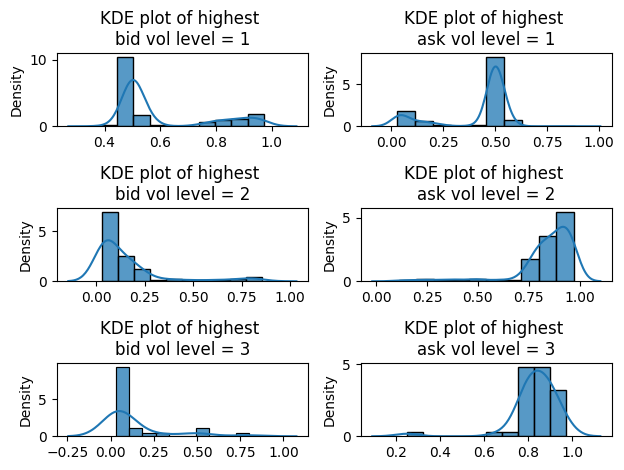

In [187]:
"""
Using only 10 bins to prevent histplot making kdeplot miniscule
"""

fig,ax = plt.subplots(nrows=3,ncols=2)
ax[0,0].set_title('KDE plot of highest \nbid vol level = 1')
ax[1,0].set_title('KDE plot of highest \nbid vol level = 2')
ax[2,0].set_title('KDE plot of highest \nbid vol level = 3')
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==1],ax=ax[0,0])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==2],ax=ax[1,0])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==3],ax=ax[2,0])
sns.histplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==1],ax=ax[0,0],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==2],ax=ax[1,0],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==3],ax=ax[2,0],stat='density',bins=10)


ax[0,1].set_title('KDE plot of highest \nask vol level = 1')
ax[1,1].set_title('KDE plot of highest \nask vol level = 2')
ax[2,1].set_title('KDE plot of highest \nask vol level = 3')
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==1],ax=ax[0,1])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==2],ax=ax[1,1])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==3],ax=ax[2,1])
sns.histplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==1],ax=ax[0,1],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==2],ax=ax[1,1],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==3],ax=ax[2,1],stat='density',bins=10)


fig.tight_layout()

From the above KDEplots, we see that there is a correlation between the highest volume levels and the micro-price relative to the spread. Seems to roughly follow our whaleLP for kelp in how it'd place orders (i.e. if there is a high microprice move your asks away and your bids close, if the microprice is low move your asks close and bids away).

# Study 1.5: Looking into the correlation between the microprice relative to spread and the bid-ask levels (just to see if this is accounted for if we use just microprice). (RAINFOREST RESIN)

In [188]:
micro_price = resin_data['micro_price']
micro_price_rel_spread = (micro_price-resin_data['bid_price_1'])/(resin_data['ask_price_1']-resin_data['bid_price_1'])
volumetric_data = resin_data[['timestamp','bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3',]]
mapping_dict = {'bid_volume_1':1,'bid_volume_2':2,'bid_volume_3':3}
volumetric_data['highest_bid_vol_level'] = volumetric_data[['bid_volume_1','bid_volume_2','bid_volume_3']].idxmax(axis=1).map(mapping_dict)
mapping_dict = {'ask_volume_1':1,'ask_volume_2':2,'ask_volume_3':3}
volumetric_data['highest_ask_vol_level'] = volumetric_data[['ask_volume_1','ask_volume_2','ask_volume_3']].idxmax(axis=1).map(mapping_dict)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_3780\2736205939.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumetric_data['highest_bid_vol_level'] = volumetric_data[['bid_volume_1','bid_volume_2','bid_volume_3']].idxmax(axis=1).map(mapping_dict)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_3780\2736205939.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumetric_data['highest_ask_vol_level'] = volumetric_data[['ask_volume_1','ask_volume_2','ask_volume_3']].idxmax(axis=1).map(mapping_dict)


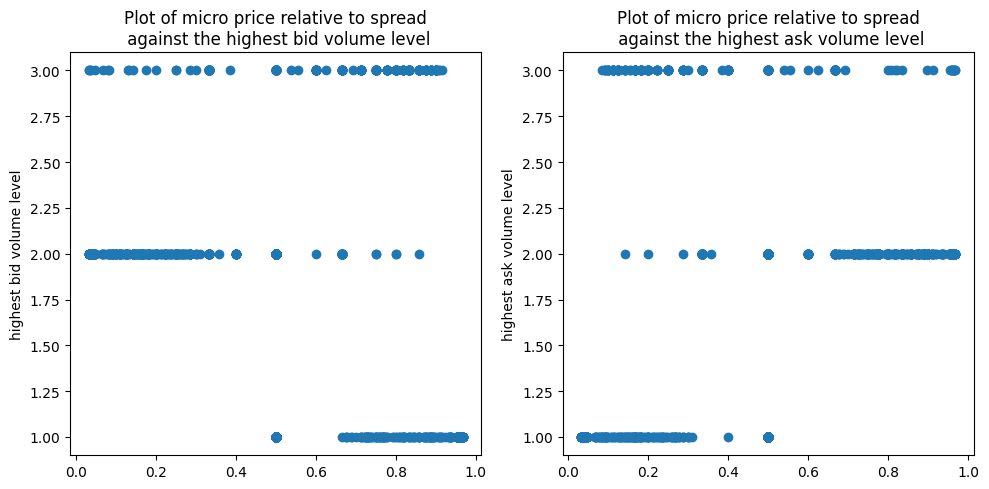

In [189]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,5))
ax[0].scatter(micro_price_rel_spread,volumetric_data['highest_bid_vol_level'])
ax[0].set_title('Plot of micro price relative to spread\n against the highest bid volume level')
ax[0].set_ylabel('highest bid volume level')
ax[1].scatter(micro_price_rel_spread,volumetric_data['highest_ask_vol_level'])
ax[1].set_title('Plot of micro price relative to spread\n against the highest ask volume level')
ax[1].set_ylabel('highest ask volume level')
fig.tight_layout()

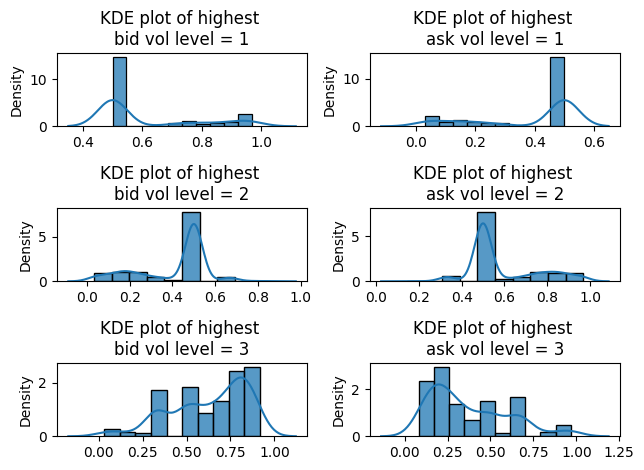

In [190]:
"""
Using only 10 bins to prevent histplot making kdeplot miniscule
"""

fig,ax = plt.subplots(nrows=3,ncols=2)
ax[0,0].set_title('KDE plot of highest \nbid vol level = 1')
ax[1,0].set_title('KDE plot of highest \nbid vol level = 2')
ax[2,0].set_title('KDE plot of highest \nbid vol level = 3')
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==1],ax=ax[0,0])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==2],ax=ax[1,0])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==3],ax=ax[2,0])
sns.histplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==1],ax=ax[0,0],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==2],ax=ax[1,0],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_bid_vol_level']==3],ax=ax[2,0],stat='density',bins=10)


ax[0,1].set_title('KDE plot of highest \nask vol level = 1')
ax[1,1].set_title('KDE plot of highest \nask vol level = 2')
ax[2,1].set_title('KDE plot of highest \nask vol level = 3')
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==1],ax=ax[0,1])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==2],ax=ax[1,1])
sns.kdeplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==3],ax=ax[2,1])
sns.histplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==1],ax=ax[0,1],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==2],ax=ax[1,1],stat='density',bins=10)
sns.histplot(micro_price_rel_spread[volumetric_data['highest_ask_vol_level']==3],ax=ax[2,1],stat='density',bins=10)


fig.tight_layout()

There is a weaker relationship for resin than for kelp. We see the market reverting nature from the fact that the bots move asks away when the microprice is low and bots move bids away when the microprice is high, i.e. when the market is going down the bots try to buy and for the converse they try to sell to move the market back to 10k mean. --> Perfect for whaleLP (probably)

# Study 1.6: Closer look at the turning points of KELP data.

# Study 1.7: How Avandella Stoikov quotes would compare to those collectively provided by the bots.